#Importing necessary Modules and Libraries

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import roc_curve, auc
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Embedding
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#Combining YouTube Spam Datasets

In [ ]:

file_names = ['Youtube01-Psy.csv', 'Youtube02-KatyPerry.csv', 'Youtube03-LMFAO.csv', 'Youtube04-Eminem.csv', 'Youtube05-Shakira.csv']
dfs = [pd.read_csv(file) for file in file_names]
df = pd.concat(dfs, ignore_index=True)
df.head()



,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1


#Preprocessing

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()


    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    text = ' '.join(text)

    return text


df['processed_content'] = df['CONTENT'].apply(preprocess_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS,processed_content
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1,huh anyway check tube channel kobyoshi
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1,hey guy check new channel first vid u monkey m...
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1,test say murdev com
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1,shaking sexy as channel enjoy _
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1,watch v vtarggvgtwq check


#Feature engineering

In [ ]:
df['text_length'] = df['CONTENT'].apply(len)
df['word_count'] = df['CONTENT'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['CONTENT'].apply(lambda x: sum(len(word) for word in x.split()) / len(x.split()))
df['exclamation_count'] = df['CONTENT'].apply(lambda x: x.count('!'))
df['question_count'] = df['CONTENT'].apply(lambda x: x.count('?'))
df['uppercase_count'] = df['CONTENT'].apply(lambda x: sum(1 for word in x.split() if word.isupper()))

print("First % rows with new features:")
print(df[['CONTENT', 'text_length', 'word_count', 'avg_word_length', 'exclamation_count', 'question_count', 'uppercase_count']].head())


First % rows with new features:
                                             CONTENT  text_length  word_count  \
0  Huh, anyway check out this you[tube] channel: ...           56           8   
1  Hey guys check out my new channel and our firs...          166          30   
2             just for test I have to say murdev.com           38           8   
3   me shaking my sexy ass on my channel enjoy ^_^ ﻿           48          11   
4            watch?v=vtaRGgvGtWQ   Check this out .﻿           39           5   

   avg_word_length  exclamation_count  question_count  uppercase_count  
0         6.125000                  0               0                0  
1         4.500000                  7               0                5  
2         3.875000                  0               0                1  
3         3.454545                  0               0                0  
4         6.600000                  0               1                0  


# TFid Vectorization

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed_content']).toarray()
y = df['CLASS'].values

print(f"Shape of the feature matrix (X): {X.shape}")
print(f"Shape of the labels vector (y): {y.shape}")


feature_names = tfidf.get_feature_names_out()
print(f"Number of features: {len(feature_names)}")


print(f"Sample feature vector (first row): {X[0]}")
print(f"Feature vector length for the sample: {len(X[0])}")

Shape of the feature matrix (X): (1956, 3290)
Shape of the labels vector (y): (1956,)
Number of features: 3290
Sample feature vector (first row): [0. 0. 0. ... 0. 0. 0.]
Feature vector length for the sample: 3290


# Label encoding & balancing

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['CLASS'])

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


print(f"Original feature matrix shape: {X.shape}")
print(f"Resampled feature matrix shape: {X_resampled.shape}")

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Original feature matrix shape: (1956, 3290)
Resampled feature matrix shape: (2010, 3290)


# Logistic Regression


Accuracy: 0.8826530612244898
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       176
           1       0.95      0.83      0.89       216

    accuracy                           0.88       392
   macro avg       0.88      0.89      0.88       392
weighted avg       0.89      0.88      0.88       392

Confusion Matrix:
[[166  10]
 [ 36 180]]


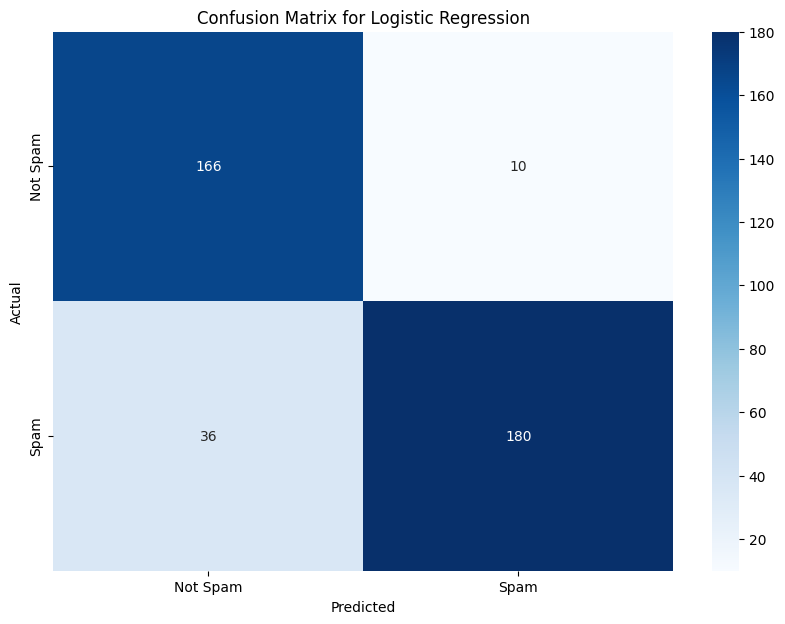

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
report_logistic = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report_logistic}")
print(f"Confusion Matrix:\n{conf_matrix}")

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()


#Random Forest

Accuracy: 0.8801020408163265
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86       176
           1       0.87      0.93      0.89       216

    accuracy                           0.88       392
   macro avg       0.88      0.87      0.88       392
weighted avg       0.88      0.88      0.88       392

Confusion Matrix:
 [[145  31]
 [ 16 200]]


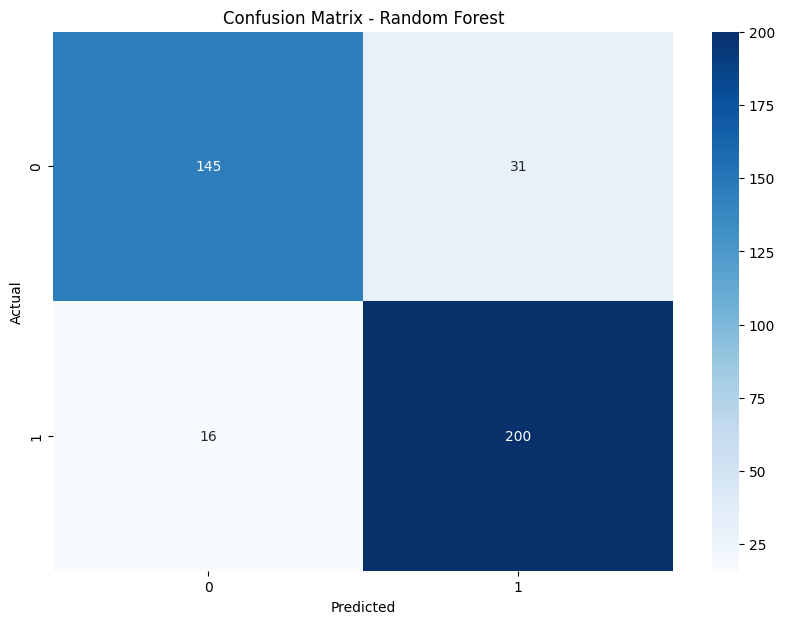

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_predictions))



plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# SVM

SVM Results:
Accuracy: 0.8852040816326531
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.95      0.88       176
           1       0.95      0.83      0.89       216

    accuracy                           0.89       392
   macro avg       0.89      0.89      0.89       392
weighted avg       0.89      0.89      0.89       392

Confusion Matrix:
 [[167   9]
 [ 36 180]]


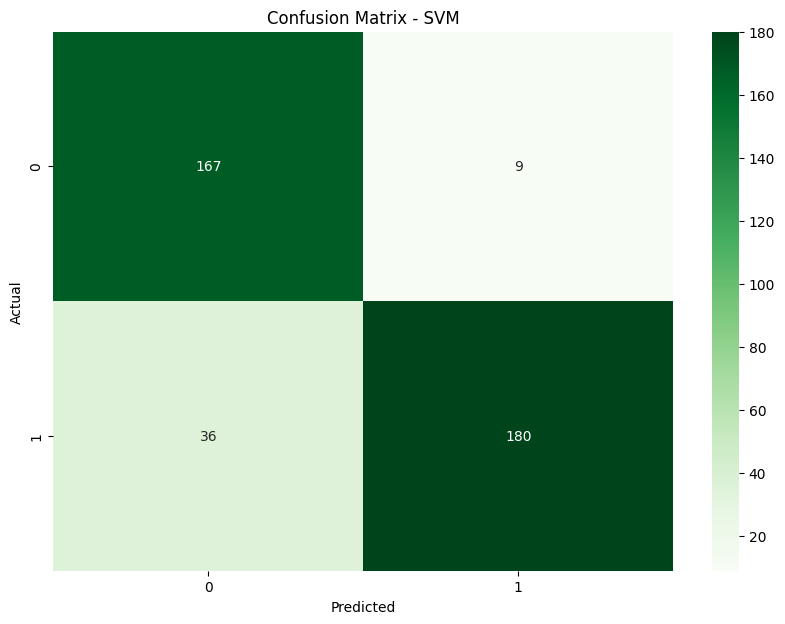

In [ ]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)


print("SVM Results:")
print("Accuracy:", accuracy_score(y_test, svm_predictions))
print("Classification Report:\n", classification_report(y_test, svm_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_predictions))

plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, svm_predictions), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ML Model Comparison

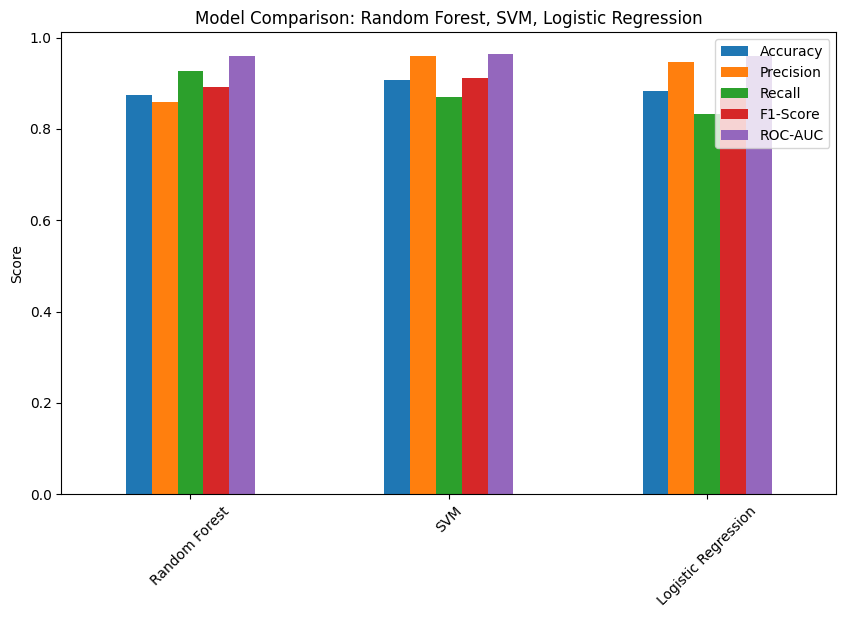

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

results_df = pd.DataFrame(results).T

models = ["Random Forest", "SVM", "Logistic Regression"]
results = results_df.loc[models]
results.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison: Random Forest, SVM, Logistic Regression")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

#ANN


In [ ]:
model = Sequential()
model.add(Dense(units=512, activation='relu', input_shape=(X.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid'))


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       1,684,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,816,577 (6.93 MB)

 Trainable params: 1,816,577 (6.93 MB)

 Non-trainable params: 0 (0.00 B)

# Training ANN

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6815 - loss: 0.6662 - val_accuracy: 0.8786 - val_loss: 0.4373
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9166 - loss: 0.3315 - val_accuracy: 0.8914 - val_loss: 0.2262
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9641 - loss: 0.0969 - val_accuracy: 0.9073 - val_loss: 0.1992
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9780 - loss: 0.0554 - val_accuracy: 0.9073 - val_loss: 0.2012
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9903 - loss: 0.0361 - val_accuracy: 0.9105 - val_loss: 0.2258
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9914 - loss: 0.0287 - val_accuracy: 0.9105 - val_loss: 0.2211
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9916 - loss: 0.0221 - val_accuracy: 0.9105 - val_loss: 0.2401
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accuracy: 0.9073 - v

# ROC & AUC

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


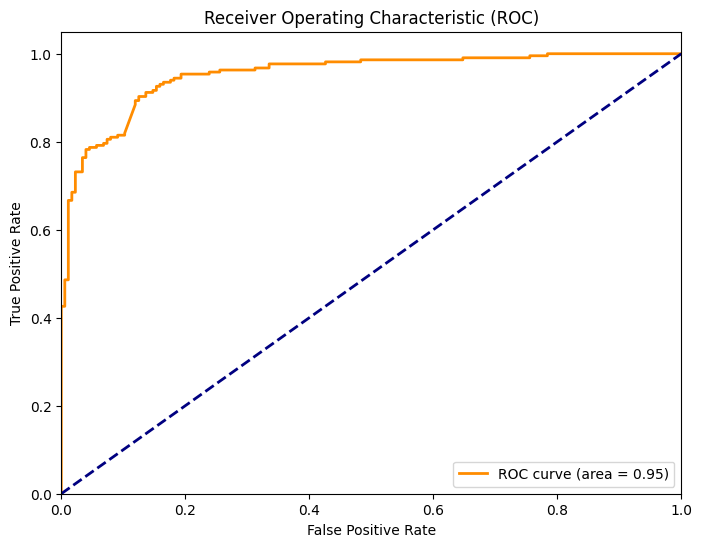

In [ ]:
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


# Plot training and validation accuracy

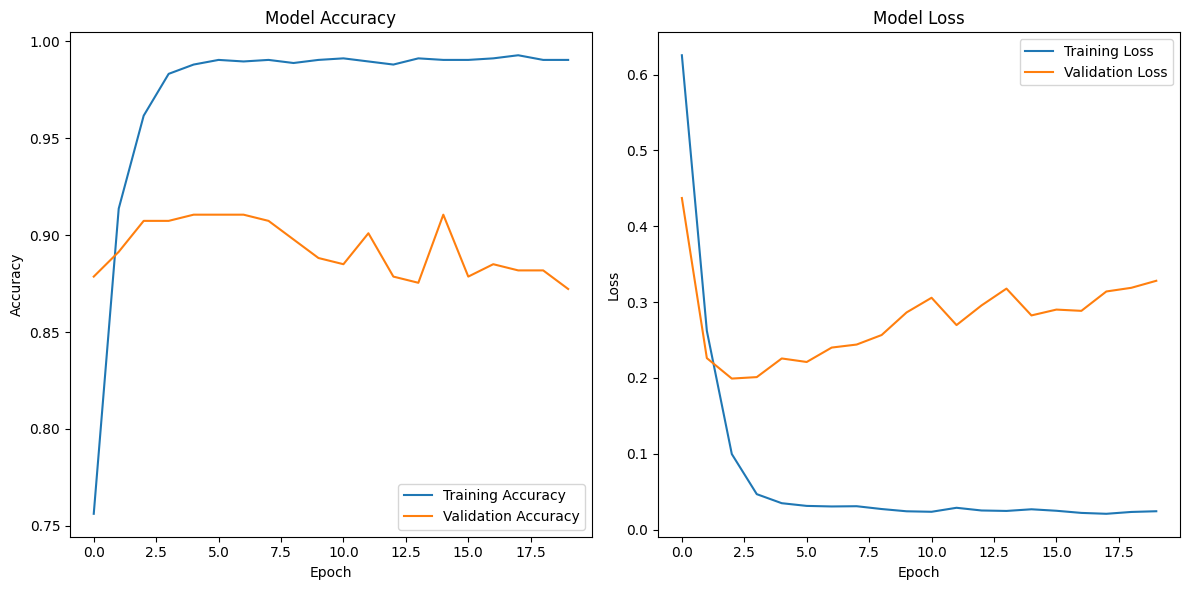

In [ ]:
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ANN Result


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8894 - loss: 0.4312
Test Accuracy: 0.8852040767669678
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy: 0.8852040816326531
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.86       176
           1       0.86      0.95      0.90       216

    accuracy                           0.89       392
   macro avg       0.89      0.88      0.88       392
weighted avg       0.89      0.89      0.88       392

Confusion Matrix:
[[142  34]
 [ 11 205]]


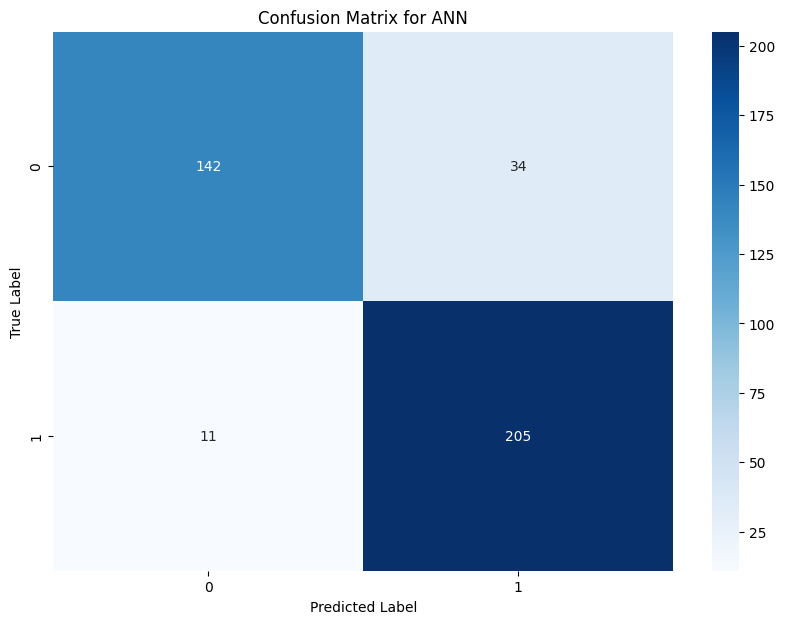

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')


y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")


accuracy = accuracy_score(y_test, y_pred)
report_ann = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report_ann}")
print(f"Confusion Matrix:\n{conf_matrix}")

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ANN')
plt.show()


 # LSTM

In [ ]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=X.shape[1], output_dim=128, input_length=X.shape[1]))
model_lstm.add(LSTM(128, return_sequences=False))


model_lstm.add(Dense(128, activation='relu'))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(1, activation='sigmoid'))


model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_lstm.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

history_lstm = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9903 - loss: 0.0260 - val_accuracy: 0.8850 - val_loss: 0.2988
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9926 - loss: 0.0201 - val_accuracy: 0.8850 - val_loss: 0.3036
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9935 - loss: 0.0229 - val_accuracy: 0.9010 - val_loss: 0.2897
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9896 - loss: 0.0198 - val_accuracy: 0.8850 - val_loss: 0.3119
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9914 - loss: 0.0228 - val_accuracy: 0.8818 - val_loss: 0.3090
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9886 - loss: 0.0284 - val_accuracy: 0.8722 - val_loss: 0.3455
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9895 - loss: 0.0282 - val_accuracy: 0.8722 - val_loss: 0.3430
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9879 - loss: 0.0276 - val_accuracy: 0.8882 - v

# LSTM Results


13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.4262 - loss: 0.6932
Test Accuracy for LSTM: 0.44897958636283875
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.45      1.00      0.62       176
           1       0.00      0.00      0.00       216

    accuracy                           0.45       392
   macro avg       0.22      0.50      0.31       392
weighted avg       0.20      0.45      0.28       392

LSTM Confusion Matrix:
[[176   0]
 [216   0]]


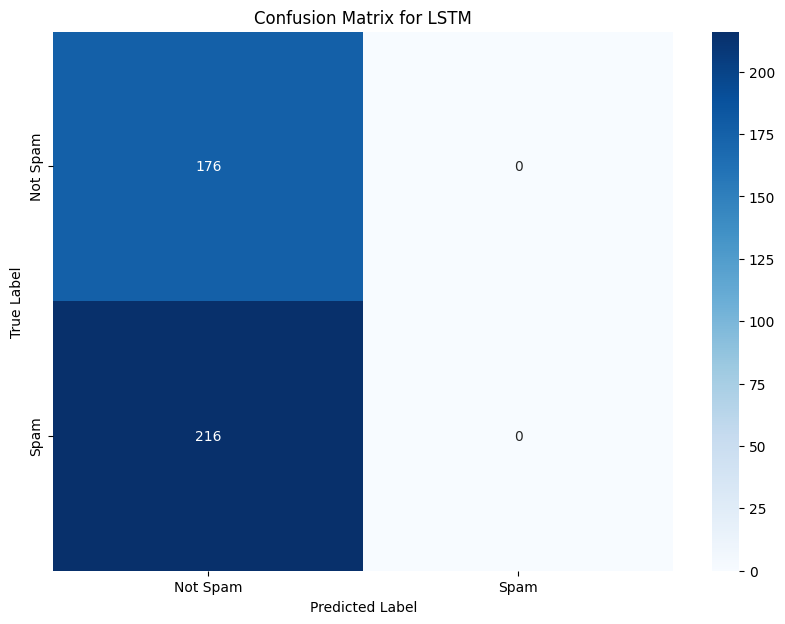

In [ ]:
loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test, y_test)
print(f'Test Accuracy for LSTM: {accuracy_lstm}')


y_pred_prob_lstm = model_lstm.predict(X_test)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype("int32")
report_lstm = classification_report(y_test, y_pred_lstm)
conf_matrix_lstm = confusion_matrix(y_test, y_pred_lstm)

print(f"LSTM Classification Report:\n{report_lstm}")
print(f"LSTM Confusion Matrix:\n{conf_matrix_lstm}")


plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LSTM')
plt.show()
